In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')


Using cuda device


In [ ]:
# 데이터 로딩
path = 'https://bit.ly/ds_boston_csv'
data = pd.read_csv(path)


# x, y 분할
target = 'medv'
features = ['lstat', 'ptratio', 'crim']  #3개만 가져오기
x = data.loc[:, features]
y = data.loc[:, target]


# train, val 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.2, random_state = 20)


# 스케일러 선언
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


In [ ]:
# 데이터 로더 함수
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor) #학습데이터셋을 만듬


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)


    return train_loader, x_val_tensor, y_val_tensor


In [6]:
# 데이터프레임을 넘파이 배열로 변환
print(type(y_train), type(y_val))
y_train = y_train.values
y_val = y_val.values
print(type(y_train), type(y_val))


<class 'pandas.Series'> <class 'pandas.Series'>
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [ ]:
# make_DataSet 함수로 데이터 로더를 구성
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)


# 첫 번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
    print(f'Shape of x [rows, columns]: {x.shape}')
    print(f'Shape of y: {y.shape} {y.dtype}')
    break    #어떤 데이터가 들어가는지 확인만 하는용도 ->  [32,3] 이 들어가고 [32,1] 나옴   
#batch_size = 32이기때문에 32가 나옴


Shape of x [rows, columns]: torch.Size([32, 3])
Shape of y: torch.Size([32, 1]) torch.float32


In [8]:
n_feature = x.shape[1]
model1 = nn.Sequential(nn.Linear(n_feature, 1)).to(device)


loss_fn = nn.MSELoss()
optimizer = Adam(model1.parameters(), lr=0.01)
print(model1)


Sequential(
  (0): Linear(in_features=3, out_features=1, bias=True)
)


In [ ]:

#train 함수
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    tr_loss = 0
    model.train()
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    tr_loss /= num_batches
    return tr_loss.item()


In [ ]:
#평가 함수
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()   #반드시 이발모드로 바꿔줘야함
    with torch.no_grad():  #no grad를 하면 학습안해도됨  -> 왜냐하면 이건 평가함수이기 때문에
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        val_loss = loss_fn(pred, y).item()
    return val_loss, pred



In [13]:
#200번 cuda 돌아가게 함epochs = 200
epochs = 200
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(x_val_ts, y_val_ts, model1, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss: {tr_loss:4f}, val loss: {val_loss:4f}')



Epoch 1, train loss: 116.961761, val loss: 81.677673
Epoch 2, train loss: 119.092964, val loss: 81.434906
Epoch 3, train loss: 113.445320, val loss: 81.185410
Epoch 4, train loss: 114.566635, val loss: 80.944260
Epoch 5, train loss: 115.550591, val loss: 80.694611
Epoch 6, train loss: 113.773956, val loss: 80.439667
Epoch 7, train loss: 115.020775, val loss: 80.203186
Epoch 8, train loss: 112.278946, val loss: 79.953239
Epoch 9, train loss: 112.243835, val loss: 79.715759
Epoch 10, train loss: 112.002914, val loss: 79.470810
Epoch 11, train loss: 110.676796, val loss: 79.220619
Epoch 12, train loss: 109.875076, val loss: 78.990997
Epoch 13, train loss: 111.401161, val loss: 78.751724
Epoch 14, train loss: 109.660271, val loss: 78.519760
Epoch 15, train loss: 110.539139, val loss: 78.270454
Epoch 16, train loss: 109.923599, val loss: 78.029655
Epoch 17, train loss: 110.264442, val loss: 77.799141
Epoch 18, train loss: 108.106705, val loss: 77.568649
Epoch 19, train loss: 109.217415, val

In [ ]:
# 학습곡선 함수   - 학습 확인할 수 있는 함수
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()



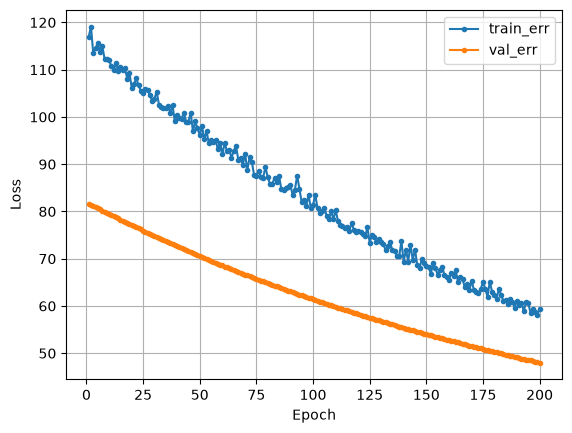

In [20]:
  # 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)

In [21]:
_, pred = evaluate(x_val_ts, y_val_ts, model1, loss_fn, device)
mae = mean_absolute_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
print(f'MAE : {mae}')
print(f'MAPE : {mape}')



MAE : 4.928329944610596
MAPE : 0.23889099061489105
